# Introduction to Regression with Neural Networks in TensorFlow

There are many definitions for a [regression problem](https://en.wikipedia.org/wiki/Regression_analysis) but in our case, we're going to simplify it to be: predicting a continuous number.

For example, you might want to:
- Predict the selling price of houses given information about them (such as number of rooms, size, number of bathrooms).
- Predict the coordinates of a bounding box of an item in an image.
- Predict the cost of medical insurance for an individual given their demographics (age, sex, gender, race).

We're going to set the foundations for how to take a sample of inputs (this is your data), build a neural network to discover patterns in those inputs and then make a prediction (in the form of a number) based on those inputs.

## What we're going to cover

Specifically, we're going to go through doing the following with TensorFlow:
- Architecture of a regression model
- Input shapes and output shapes
  - `X`: features/data (inputs)
  - `y`: labels (outputs)
- Creating custom data to view and fit
- Steps in modelling
  - Creating a model
  - Compiling a model
    - Defining a loss function
    - Setting up an optimizer
    - Creating evaluation metrics
  - Fitting a model (getting it to find patterns in our data)
- Evaluating a model
  - Visualizng the model
  - Looking at training curves
  - Compare predictions to ground truth (using our evaluation metrics)
- Saving a model (so we can use it later)
- Loading a model

## Typical architecture of a regresison neural network

Following is a generic setup for ingesting a collection of numbers, finding patterns in them and then outputing some kind of target number.


| **Hyperparameter** | **Typical value** |
| --- | --- |
| Input layer shape | Same shape as number of features (e.g. 3 for # bedrooms, # bathrooms, # car spaces in housing price prediction) |
| Hidden layer(s) | Problem specific, minimum = 1, maximum = unlimited |
| Neurons per hidden layer | Problem specific, generally 10 to 100 |
| Output layer shape | Same shape as desired prediction shape (e.g. 1 for house price) |
| Hidden activation | Usually [ReLU](https://www.kaggle.com/dansbecker/rectified-linear-units-relu-in-deep-learning) (rectified linear unit) |
| Output activation | None, ReLU, logistic/tanh |
| Loss function | [MSE](https://en.wikipedia.org/wiki/Mean_squared_error) (mean square error) or [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) (mean absolute error)/Huber (combination of MAE/MSE) if outliers |
| Optimizer | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD) (stochastic gradient descent), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) |



> 🔑 **Note:** A **hyperparameter** in machine learning is something a data analyst or developer can set themselves, where as a **parameter** usually describes something a model learns on its own (a value not explicitly set by an analyst).

In [1]:
# importing Necessary Libraries:
import os
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # '2' means "Show me Errors only, hide Info and Warnings"
warnings.filterwarnings('ignore') # Hide the "FutureWarning" (Python logs)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
# Creating Random Linear Data:

# Features / Independent Variables:
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Label / Target / Dependent Variable:
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

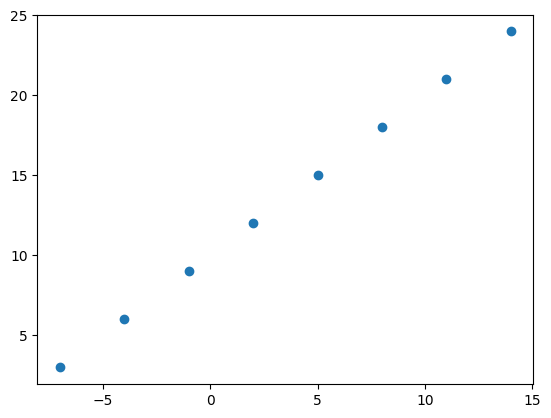

In [3]:
# Visualizing Data:

plt.scatter(X, y)
plt.show()

#### Input shapes and output shapes

One of the most important concepts when working with neural networks are the input and output shapes.

The **input shape** is the shape of your data that goes into the model.

The **output shape** is the shape of your data you want to come out of your model.

These will differ depending on the problem you're working on.

Neural networks accept numbers and output numbers. These numbers are typically represented as tensors (or arrays).

Before, we created data using NumPy arrays, but we could do the same with tensors.

In [4]:
X = tf.constant(X)
y = tf.constant(y)

I0000 00:00:1767618886.371562   44203 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
X, y

(<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

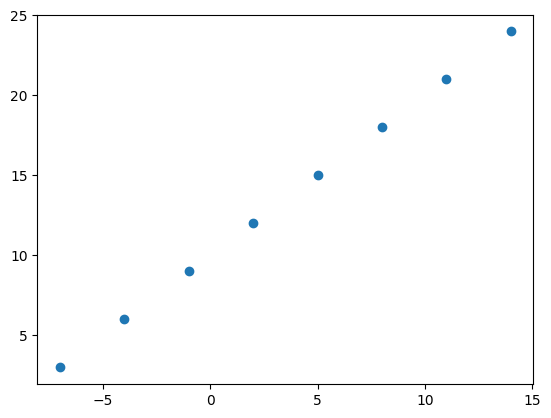

In [6]:
plt.scatter(X, y)
plt.show()

Our goal here will be to use `X` to predict `y`.

So our **input** will be `X` and our **output** will be `y`.

Knowing this, what do you think our input and output shapes will be?

In [7]:
input_shape = X[0].shape
output_shape = y[0].shape

print(input_shape, output_shape)

() ()


From this it seems our inputs and outputs have no shape?

How could that be?

It's because no matter what kind of data we pass to our model, it's always going to take as input and return as ouput some kind of tensor.

But in our case because of our dataset (only 2 small lists of numbers), we're looking at a special kind of tensor, more specificially a rank 0 tensor or a scalar.

In [8]:
X[0], y[0]

(<tf.Tensor: shape=(), dtype=float64, numpy=-7.0>,
 <tf.Tensor: shape=(), dtype=float64, numpy=3.0>)

In our case, we're trying to build a model to predict the pattern between `X[0]` equalling `-7.0` and `y[0]` equalling `3.0`.

So now we get our answer, we're trying to use 1 `X` value to predict 1 `y` value.

The concepts of input and output shapes to a model are fundamental. 

In fact, they're probably two of the things we'll spend the most time on when we work with neural networks: **making sure your input and outputs are in the correct shape**.

![example of input and output shapes for a housing price prediction problem](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/01-input-and-output-shapes-housing-prices.png)
*If you were working on building a machine learning algorithm for predicting housing prices, your inputs may be number of bedrooms, number of bathrooms and number of garages, giving you an input shape of 3 (3 different features). And since you're trying to predict the price of the house, your output shape would be 1.*

In [9]:
X.shape

TensorShape([8])

In [10]:
X

<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>

In [11]:
tf.reshape(X, shape= (8,1))

<tf.Tensor: shape=(8, 1), dtype=float64, numpy=
array([[-7.],
       [-4.],
       [-1.],
       [ 2.],
       [ 5.],
       [ 8.],
       [11.],
       [14.]])>

We will need to reshape X as Models in tensorflow Requires Input Dimension to be Atleast 2.

#### Steps in modelling

Now we know what data we have as well as the input and output shapes, let's see how we'd build a neural network to model it.

In TensorFlow, there are typically 3 fundamental steps to creating and training a model.

1. **Creating a model** - piece together the layers of a neural network yourself (using the [Functional](https://www.tensorflow.org/guide/keras/functional) or [Sequential API](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential)) or import a previously built model (known as transfer learning).
2. **Compiling a model** - defining how a models performance should be measured (loss/metrics) as well as defining how it should improve (optimizer). 
3. **Fitting a model** - letting the model try to find patterns in the data (how does `X` get to `y`). 

Let's see these in action using the [Keras Sequential API](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential) to build a model for our regression data. And then we'll step through each.

In [12]:
from tensorflow.keras import Sequential # To Create Model Using Sequential API
from tensorflow.keras.layers import Dense # To Create Dense Neurons in Network

In [13]:
tf.random.set_seed(42) # To Produce same results every time.

base_model = Sequential() # Creating a Sequential Model

base_model.add(Dense(units= 1)) # Adding One Dense Neuron in Model

# Compiling The Model
base_model.compile(loss= 'mae', # Mean Absolute Error
                  optimizer= 'sgd', # SGD = Stochastic Gradient Descent
                  metrics= ['mae'])

# Fitting The Model with Data
base_model.fit(tf.reshape(X, shape= (8,1)),
               y, 
               epochs= 5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 20.8303 - mae: 20.8303
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 20.4656 - mae: 20.4656
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 20.1843 - mae: 20.1843
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 19.9031 - mae: 19.9031

I0000 00:00:1767618888.487669   44348 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 19.9031 - mae: 19.9031
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 19.6218 - mae: 19.6218


#### Trying to Predict value of y using our Trained Model:

Keep in mind that Relationship between our Original Data is y = X + 10.

In [14]:
X

<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>

In [15]:
y

<tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>

In [16]:
X + 10

<tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>

In [17]:
# Making a Prediction Using Trained Model:
base_model.predict(tf.constant([[17.0]])) # Because we need to pass tensor to our model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


array([[-21.39086]], dtype=float32)

It doesn't go very well... it should've output something close to 27.0.
(y = X + 10) ..> X = 17 ..> y = 27.

> 🤔 **Question:** What's Keras? I thought we were working with TensorFlow but every time we write TensorFlow code, `keras` comes after `tf` (e.g. `tf.keras.layers.Dense()`)?

Before TensorFlow 2.0+, [Keras](https://keras.io/) was an API designed to be able to build deep learning models with ease. Since TensorFlow 2.0+, its functionality has been tightly integrated within the TensorFlow library.

#### Improving a model

To improve our model, we alter almost every part of the 3 steps we went through before.

1. **Creating a model** - here we might want to add more layers, increase the number of hidden units (also called neurons) within each layer, change the activation functions of each layer.
2. **Compiling a model** - you might want to choose optimization function or perhaps change the **learning rate** of the optimization function.
3. **Fitting a model** - perhaps you could fit a model for more **epochs** (leave it training for longer) or on more data (give the model more examples to learn from).

In [18]:
# Creating Improved Model by Increasing the Training Time (Number of Epochs):

tf.random.set_seed(42)

imprvd_model1 = Sequential()

imprvd_model1.add(Dense(units= 1))

imprvd_model1.compile(loss= 'mae',
                     optimizer= 'sgd',
                     metrics= ['mae'])

imprvd_model1.fit(tf.reshape(X, shape= (8,1)),
                 y,
                 epochs= 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step - loss: 15.0451 - mae: 15.0451
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 14.8388 - mae: 14.8388
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 14.7063 - mae: 14.7063
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 14.5738 - mae: 14.5738
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 14.4413 - mae: 14.4413
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 14.3088 - mae: 14.3088
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 14.1763 - mae: 14.1763
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 14.0438 - mae: 14.0438
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 13.9113 - mae: 13.9113
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 13.7788 - mae: 13.7788
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 13.6463 - mae: 13.6463
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 13.5138 - mae: 13.5138
Epoch 13/100
1/1 ━━━━━━━

MAE is down from 19.62 (in Previuos Model) to 6.83.

In [19]:
# Making a Prediction using Improved Model:
imprvd_model1.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


array([[29.463106]], dtype=float32)

Our Prediction Should be 27.

This Model is quite close to getting correct prediction than base model.

`Creating Improved Model by Increasing the Hidden layers, Number of Neurons and Using Activation Functions for layers:`

In [20]:
tf.random.set_seed(42)

imprvd_model2 = Sequential()

imprvd_model2.add(Dense(units= 10, activation= 'relu'))
imprvd_model2.add(Dense(units= 5, activation= 'relu'))
imprvd_model2.add(Dense(units= 1))

imprvd_model2.compile(loss= 'mae',
                     optimizer= 'sgd',
                     metrics= ['mae'])

imprvd_model2.fit(tf.reshape(X, shape= (8,1)),
                 y,
                 epochs= 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 14.5247 - mae: 14.5247
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 14.1589 - mae: 14.1589
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 14.0258 - mae: 14.0258
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 13.9263 - mae: 13.9263
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 13.8329 - mae: 13.8329
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 13.7673 - mae: 13.7673
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 13.7029 - mae: 13.7029
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 13.6398 - mae: 13.6398
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 13.5771 - mae: 13.5771
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 13.5191 - mae: 13.5191
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 13.4689 - mae: 13.4689
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 13.4369 - mae: 13.4369
Epoch 13/100
1/1 ━━━━━━━━━━

In [21]:
# Making a Prediction using Improved Model:
imprvd_model2.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


array([[0.99999934]], dtype=float32)

`Creating Improved Model by Changing the Optimizer and Adjusting Learning Rate:`

In [22]:
tf.random.set_seed(42)

imprvd_model3 = Sequential()

imprvd_model3.add(Dense(units= 10, activation= 'relu'))
imprvd_model3.add(Dense(units= 5, activation= 'relu'))
imprvd_model3.add(Dense(units= 1))

imprvd_model3.compile(loss= 'mae',
                     optimizer= tf.keras.optimizers.Adam(learning_rate= 0.01),
                     metrics= ['mae'])

imprvd_model3.fit(tf.reshape(X, shape= (8,1)),
                 y,
                 epochs= 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 12.1075 - mae: 12.1075
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 11.8253 - mae: 11.8253
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 11.5319 - mae: 11.5319
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 11.2268 - mae: 11.2268
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 10.9105 - mae: 10.9105
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 10.5781 - mae: 10.5781
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 10.2600 - mae: 10.2600
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 9.9909 - mae: 9.9909
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 9.7081 - mae: 9.7081
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 9.4062 - mae: 9.4062
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 9.0861 - mae: 9.0861
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 8.7476 - mae: 8.7476
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━

In [23]:
# Making a Prediction Using Improved Model:
imprvd_model3.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


array([[27.024652]], dtype=float32)

This Model is Quite Improved compared to All Previous Ones.